# Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r'D:\books\git\MLzoomcampCapstone_2\data\customer_support_tickets.csv')

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

In [5]:
data.head().T

,0,1,2,3,4
Ticket ID,1,2,3,4,5
Customer Name,Marisa Obrien,Jessica Rios,Christopher Robbins,Christina Dillon,Alexander Carroll
Customer Email,carrollallison@example.com,clarkeashley@example.com,gonzalestracy@example.com,bradleyolson@example.org,bradleymark@example.com
Customer Age,32,42,48,27,67
Customer Gender,Other,Female,Other,Female,Female
Product Purchased,GoPro Hero,LG Smart TV,Dell XPS,Microsoft Office,Autodesk AutoCAD
Date of Purchase,2021-03-22,2021-05-22,2020-07-14,2020-11-13,2020-02-04
Ticket Type,Technical issue,Technical issue,Technical issue,Billing inquiry,Billing inquiry
Ticket Subject,Product setup,Peripheral compatibility,Network problem,Account access,Data loss
Ticket Description,I'm having an issue with the {product_purchase...,I'm having an issue with the {product_purchase...,I'm facing a problem with my {product_purchase...,I'm having an issue with the {product_purchase...,I'm having an issue with the {product_purchase...


we won't use the following features:
- First Response Time	
- Time to Resolution	
- Resolution
- Customer Satisfaction Rating	
- Ticket ID
- Customer Name
- Customer Email

In [6]:
df = data.drop(columns=['First Response Time','Time to Resolution','Resolution',
                            'Customer Satisfaction Rating','Ticket ID','Customer Name',
                            'Customer Email','Ticket Status','Date of Purchase'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Customer Age        8469 non-null   int64 
 1   Customer Gender     8469 non-null   object
 2   Product Purchased   8469 non-null   object
 3   Ticket Type         8469 non-null   object
 4   Ticket Subject      8469 non-null   object
 5   Ticket Description  8469 non-null   object
 6   Ticket Priority     8469 non-null   object
 7   Ticket Channel      8469 non-null   object
dtypes: int64(1), object(7)
memory usage: 529.4+ KB


In [8]:
# removing spaces and lowercasing
df.columns = df.columns.str.lower().str.replace(' ', '_')
 
categorical_columns = list(df.dtypes[df.dtypes == 'object'].index)
 
for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')
 
df.head().T

,0,1,2,3,4
customer_age,32,42,48,27,67
customer_gender,other,female,other,female,female
product_purchased,gopro_hero,lg_smart_tv,dell_xps,microsoft_office,autodesk_autocad
ticket_type,technical_issue,technical_issue,technical_issue,billing_inquiry,billing_inquiry
ticket_subject,product_setup,peripheral_compatibility,network_problem,account_access,data_loss
ticket_description,i'm_having_an_issue_with_the_{product_purchase...,i'm_having_an_issue_with_the_{product_purchase...,i'm_facing_a_problem_with_my_{product_purchase...,i'm_having_an_issue_with_the_{product_purchase...,i'm_having_an_issue_with_the_{product_purchase...
ticket_priority,critical,critical,low,low,low
ticket_channel,social_media,chat,social_media,social_media,email


In [9]:
df.dtypes

customer_age           int64
customer_gender       object
product_purchased     object
ticket_type           object
ticket_subject        object
ticket_description    object
ticket_priority       object
ticket_channel        object
dtype: object

# Exploratory Data Analysis with Visualizations

In [10]:
# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 1. Dataset Overview

In [11]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nColumn Names: {list(df.columns)}")

Dataset Shape: (8469, 8)
Total Records: 8,469
Total Features: 8

Column Names: ['customer_age', 'customer_gender', 'product_purchased', 'ticket_type', 'ticket_subject', 'ticket_description', 'ticket_priority', 'ticket_channel']


In [12]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing Values:
customer_age          0
customer_gender       0
product_purchased     0
ticket_type           0
ticket_subject        0
ticket_description    0
ticket_priority       0
ticket_channel        0
dtype: int64

Total missing values: 0


## 2. Customer Age Distribution

In [13]:
# Age statistics
print("Customer Age Statistics:")
print(df['customer_age'].describe())

Customer Age Statistics:
count    8469.000000
mean       44.026804
std        15.296112
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: customer_age, dtype: float64


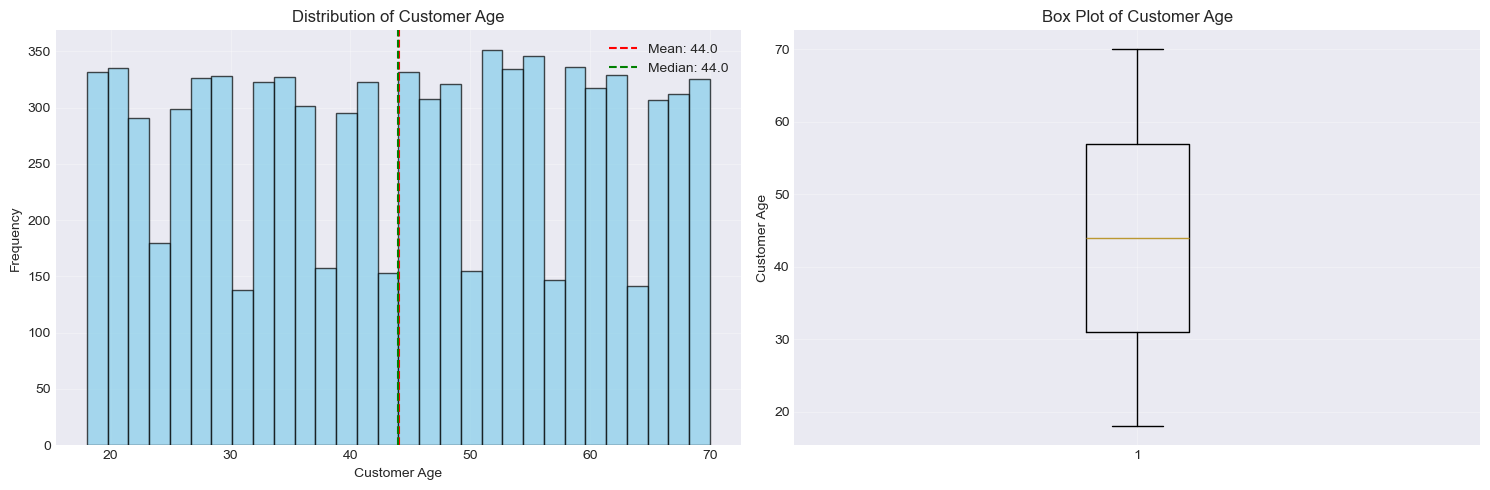

In [14]:
# Age distribution plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['customer_age'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Customer Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Customer Age')
axes[0].axvline(df['customer_age'].mean(), color='red', linestyle='--', label=f'Mean: {df["customer_age"].mean():.1f}')
axes[0].axvline(df['customer_age'].median(), color='green', linestyle='--', label=f'Median: {df["customer_age"].median():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot(df['customer_age'], vert=True)
axes[1].set_ylabel('Customer Age')
axes[1].set_title('Box Plot of Customer Age')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Customer Gender Distribution

In [15]:
# Gender distribution
print("Customer Gender Distribution:")
print(df['customer_gender'].value_counts())
print(f"\nPercentages:")
print(df['customer_gender'].value_counts(normalize=True) * 100)

Customer Gender Distribution:
customer_gender
male      2896
female    2887
other     2686
Name: count, dtype: int64

Percentages:
customer_gender
male      34.195301
female    34.089031
other     31.715669
Name: proportion, dtype: float64


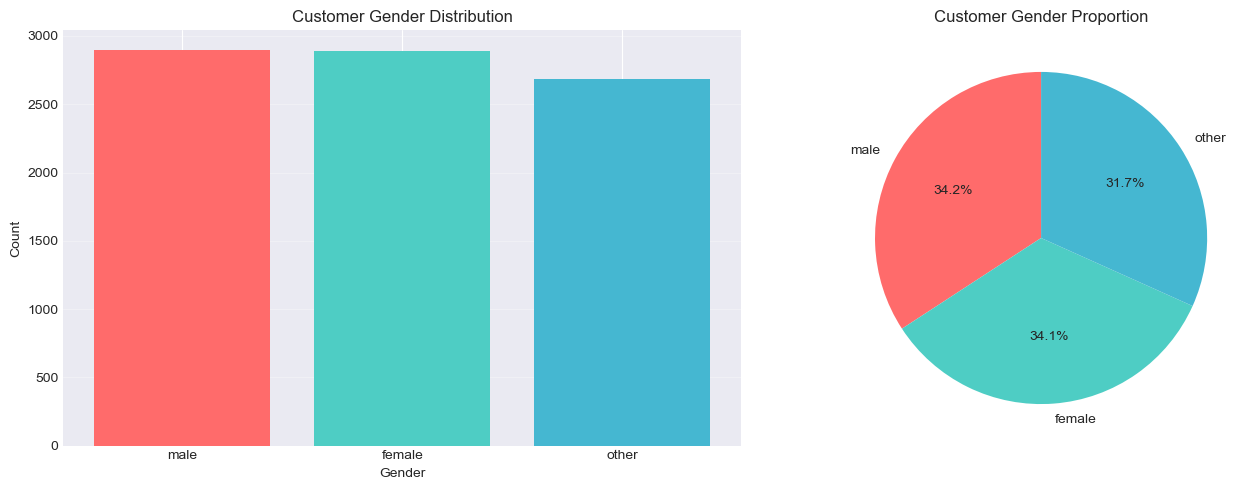

In [16]:
# Gender visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
gender_counts = df['customer_gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Count')
axes[0].set_title('Customer Gender Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#FF6B6B', '#4ECDC4', '#45B7D1'])
axes[1].set_title('Customer Gender Proportion')

plt.tight_layout()
plt.show()

## 4. Product Purchased Analysis

In [17]:
# Product distribution
print(f"Number of unique products: {df['product_purchased'].nunique()}")
print(f"\nTop 15 Products:")
print(df['product_purchased'].value_counts().head(15))

Number of unique products: 42

Top 15 Products:
product_purchased
canon_eos              240
gopro_hero             228
nest_thermostat        225
philips_hue_lights     221
amazon_echo            221
lg_smart_tv            219
sony_xperia            217
roomba_robot_vacuum    216
apple_airpods          213
lg_oled                213
iphone                 212
sony_4k_hdr_tv         210
garmin_forerunner      208
lg_washing_machine     208
canon_dslr_camera      206
Name: count, dtype: int64


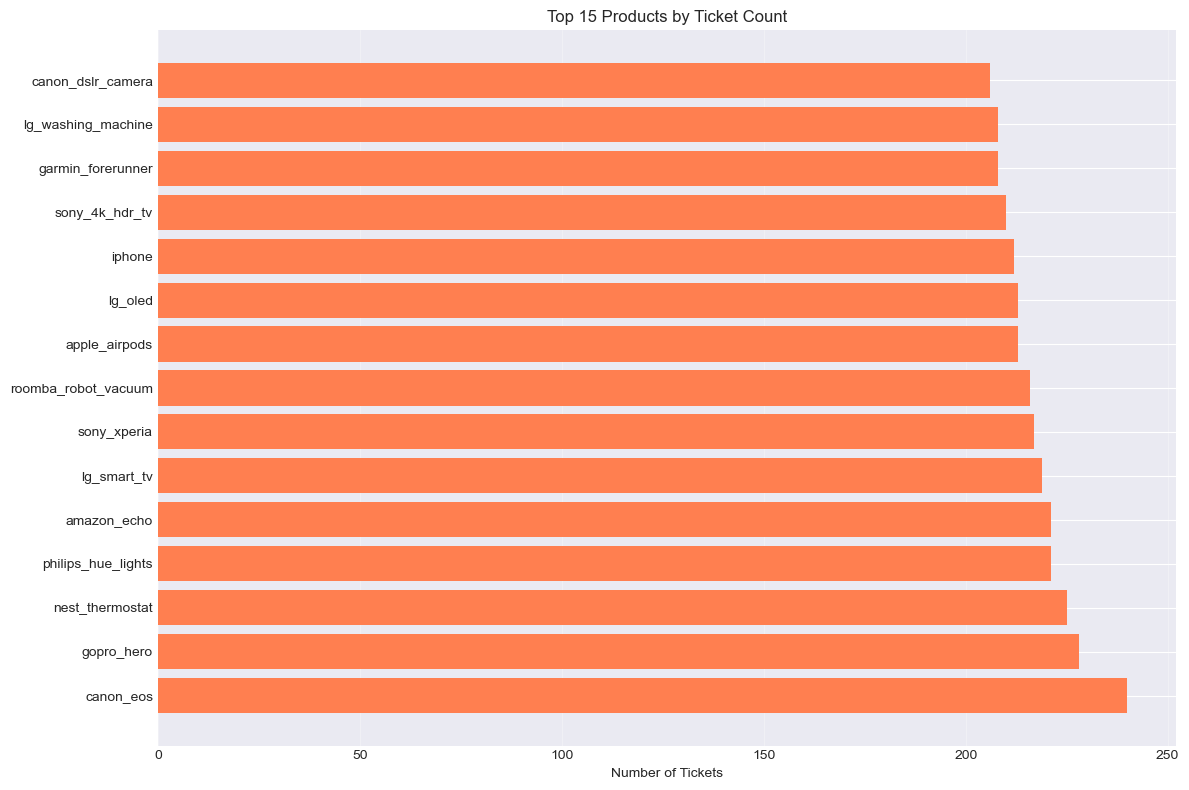

In [18]:
# Top 15 products visualization
plt.figure(figsize=(12, 8))
top_products = df['product_purchased'].value_counts().head(15)
plt.barh(range(len(top_products)), top_products.values, color='coral')
plt.yticks(range(len(top_products)), top_products.index)
plt.xlabel('Number of Tickets')
plt.title('Top 15 Products by Ticket Count')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 5. Ticket Type Analysis

In [19]:
# Ticket type distribution
print("Ticket Type Distribution:")
print(df['ticket_type'].value_counts())
print(f"\nPercentages:")
print(df['ticket_type'].value_counts(normalize=True) * 100)

Ticket Type Distribution:
ticket_type
refund_request          1752
technical_issue         1747
cancellation_request    1695
product_inquiry         1641
billing_inquiry         1634
Name: count, dtype: int64

Percentages:
ticket_type
refund_request          20.687212
technical_issue         20.628173
cancellation_request    20.014169
product_inquiry         19.376550
billing_inquiry         19.293895
Name: proportion, dtype: float64


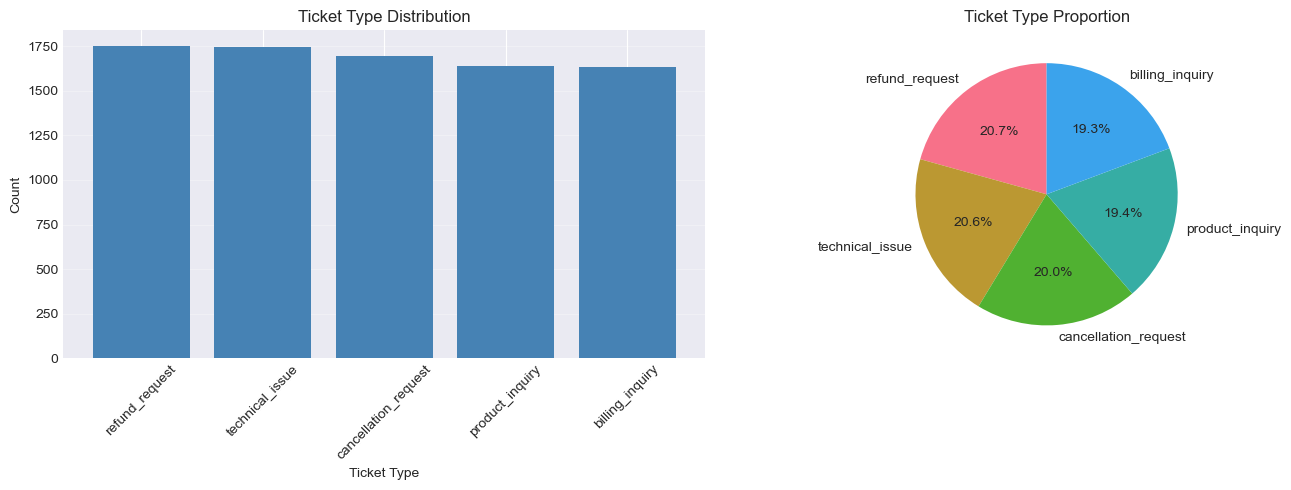

In [20]:
# Ticket type visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ticket_type_counts = df['ticket_type'].value_counts()
axes[0].bar(ticket_type_counts.index, ticket_type_counts.values, color='steelblue')
axes[0].set_xlabel('Ticket Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Ticket Type Distribution')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(ticket_type_counts.values, labels=ticket_type_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Ticket Type Proportion')

plt.tight_layout()
plt.show()

## 6. Ticket Subject Analysis

In [21]:
# Ticket subject distribution
print(f"Number of unique ticket subjects: {df['ticket_subject'].nunique()}")
print(f"\nTop 15 Ticket Subjects:")
print(df['ticket_subject'].value_counts().head(15))

Number of unique ticket subjects: 16

Top 15 Ticket Subjects:
ticket_subject
refund_request              576
software_bug                574
product_compatibility       567
delivery_problem            561
hardware_issue              547
battery_life                542
network_problem             539
installation_support        530
product_setup               529
payment_issue               526
product_recommendation      517
account_access              509
peripheral_compatibility    496
data_loss                   491
cancellation_request        487
Name: count, dtype: int64


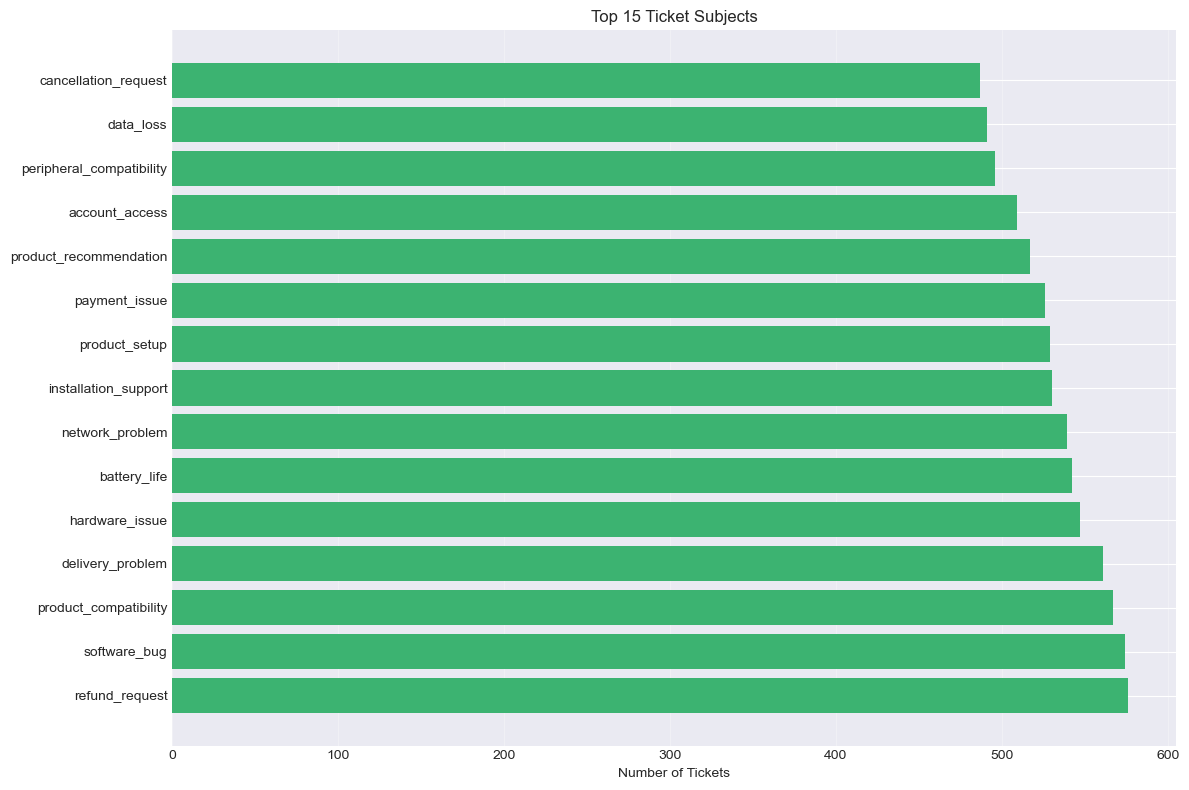

In [22]:
# Top 15 ticket subjects visualization
plt.figure(figsize=(12, 8))
top_subjects = df['ticket_subject'].value_counts().head(15)
plt.barh(range(len(top_subjects)), top_subjects.values, color='mediumseagreen')
plt.yticks(range(len(top_subjects)), top_subjects.index)
plt.xlabel('Number of Tickets')
plt.title('Top 15 Ticket Subjects')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 7. Ticket Priority Analysis

In [23]:
# Ticket priority distribution
print("Ticket Priority Distribution:")
print(df['ticket_priority'].value_counts())
print(f"\nPercentages:")
print(df['ticket_priority'].value_counts(normalize=True) * 100)

Ticket Priority Distribution:
ticket_priority
medium      2192
critical    2129
high        2085
low         2063
Name: count, dtype: int64

Percentages:
ticket_priority
medium      25.882631
critical    25.138741
high        24.619199
low         24.359429
Name: proportion, dtype: float64


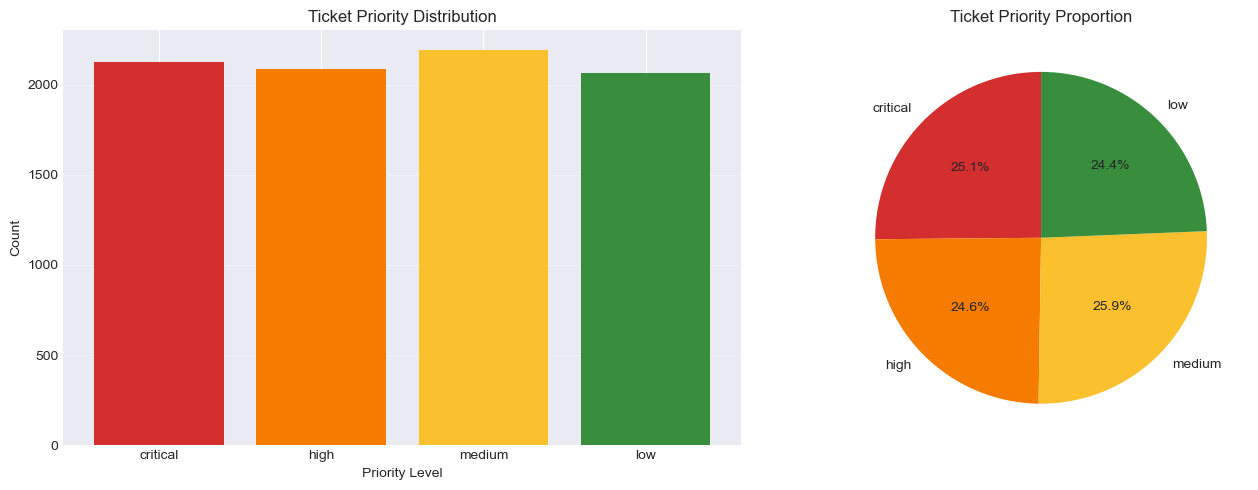

In [24]:
# Priority visualization with custom order
priority_order = ['critical', 'high', 'medium', 'low']
priority_counts = df['ticket_priority'].value_counts().reindex(priority_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
colors = ['#D32F2F', '#F57C00', '#FBC02D', '#388E3C']
axes[0].bar(priority_counts.index, priority_counts.values, color=colors)
axes[0].set_xlabel('Priority Level')
axes[0].set_ylabel('Count')
axes[0].set_title('Ticket Priority Distribution')
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(priority_counts.values, labels=priority_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Ticket Priority Proportion')

plt.tight_layout()
plt.show()

## 8. Ticket Channel Analysis

In [25]:
# Ticket channel distribution
print("Ticket Channel Distribution:")
print(df['ticket_channel'].value_counts())
print(f"\nPercentages:")
print(df['ticket_channel'].value_counts(normalize=True) * 100)

Ticket Channel Distribution:
ticket_channel
email           2143
phone           2132
social_media    2121
chat            2073
Name: count, dtype: int64

Percentages:
ticket_channel
email           25.304050
phone           25.174165
social_media    25.044279
chat            24.477506
Name: proportion, dtype: float64


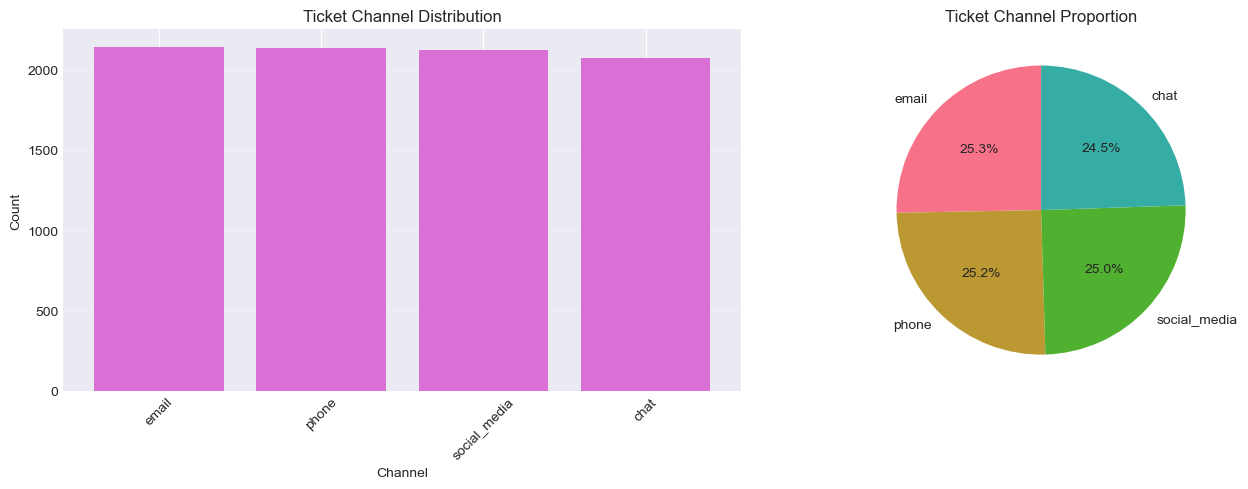

In [26]:
# Channel visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
channel_counts = df['ticket_channel'].value_counts()
axes[0].bar(channel_counts.index, channel_counts.values, color='orchid')
axes[0].set_xlabel('Channel')
axes[0].set_ylabel('Count')
axes[0].set_title('Ticket Channel Distribution')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart
axes[1].pie(channel_counts.values, labels=channel_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Ticket Channel Proportion')

plt.tight_layout()
plt.show()

## 9. Bivariate Analysis

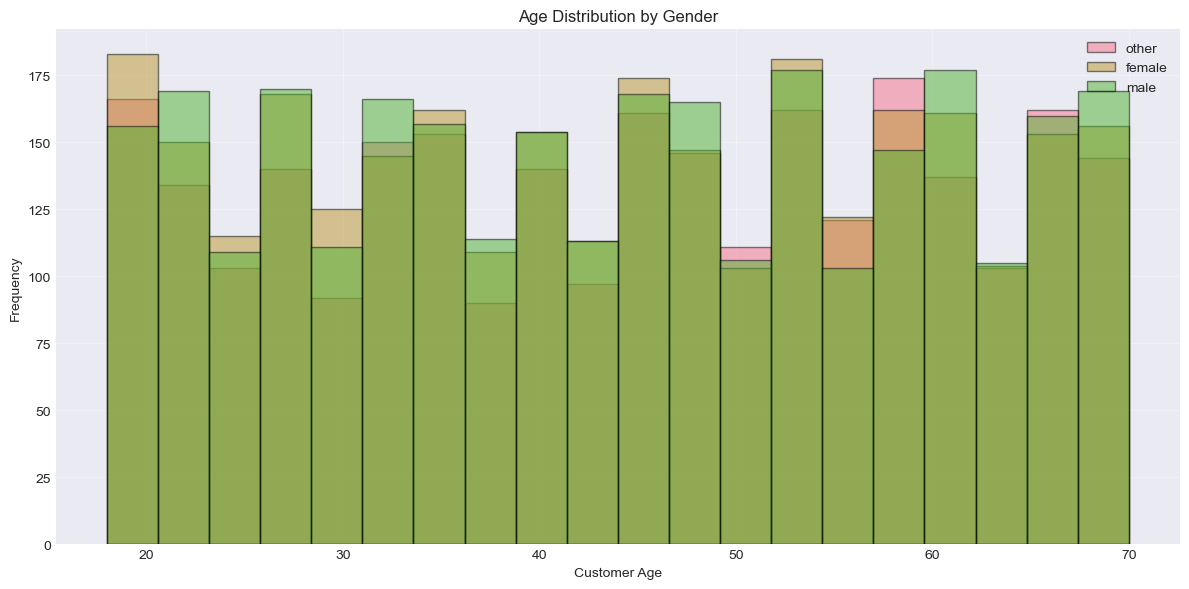

In [27]:
# Age distribution by gender
plt.figure(figsize=(12, 6))
for gender in df['customer_gender'].unique():
    subset = df[df['customer_gender'] == gender]['customer_age']
    plt.hist(subset, bins=20, alpha=0.5, label=gender, edgecolor='black')

plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.title('Age Distribution by Gender')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Ticket Priority by Type:
ticket_priority       critical  high  low  medium
ticket_type                                      
billing_inquiry            420   382  398     434
cancellation_request       423   398  414     460
product_inquiry            403   399  398     441
refund_request             444   448  440     420
technical_issue            439   458  413     437


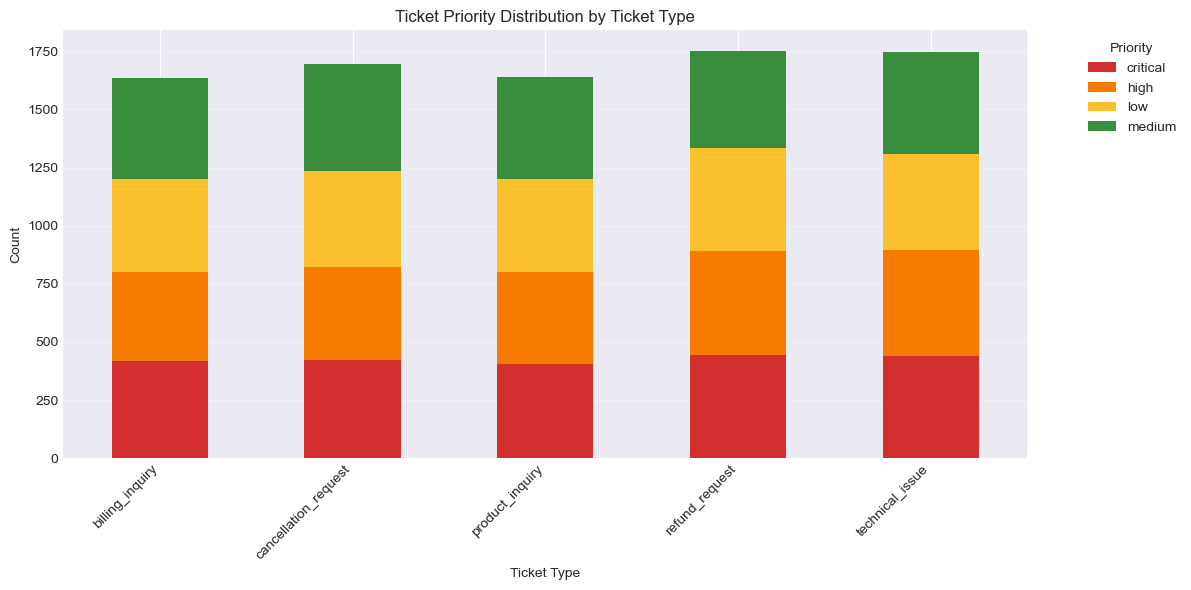

In [28]:
# Priority by ticket type
priority_type_crosstab = pd.crosstab(df['ticket_type'], df['ticket_priority'])
print("Ticket Priority by Type:")
print(priority_type_crosstab)

# Stacked bar chart
priority_type_crosstab.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#D32F2F', '#F57C00', '#FBC02D', '#388E3C'])
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.title('Ticket Priority Distribution by Ticket Type')
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Ticket Channel by Priority:
ticket_priority  critical  high  low  medium
ticket_channel                              
chat                  504   517  501     551
email                 571   504  525     543
phone                 526   512  499     595
social_media          528   552  538     503


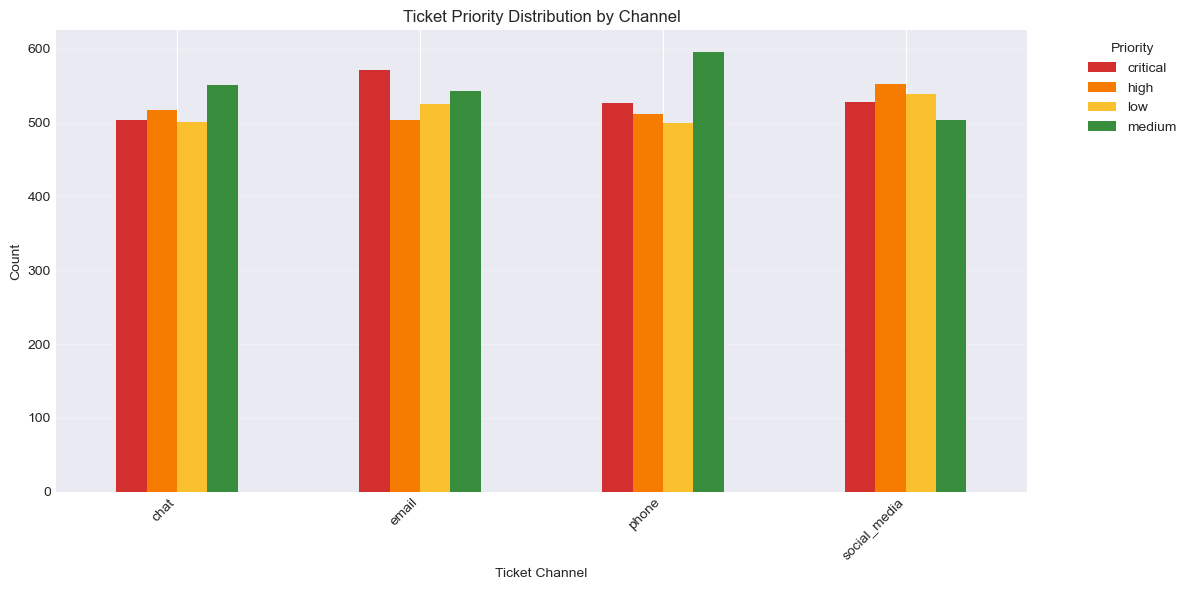

In [29]:
# Channel by priority
channel_priority_crosstab = pd.crosstab(df['ticket_channel'], df['ticket_priority'])
print("\nTicket Channel by Priority:")
print(channel_priority_crosstab)

# Grouped bar chart
channel_priority_crosstab.plot(kind='bar', figsize=(12, 6), color=['#D32F2F', '#F57C00', '#FBC02D', '#388E3C'])
plt.xlabel('Ticket Channel')
plt.ylabel('Count')
plt.title('Ticket Priority Distribution by Channel')
plt.legend(title='Priority', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


Customer Gender by Ticket Type:
customer_gender       female  male  other
ticket_type                              
billing_inquiry          561   560    513
cancellation_request     557   591    547
product_inquiry          554   558    529
refund_request           617   612    523
technical_issue          598   575    574


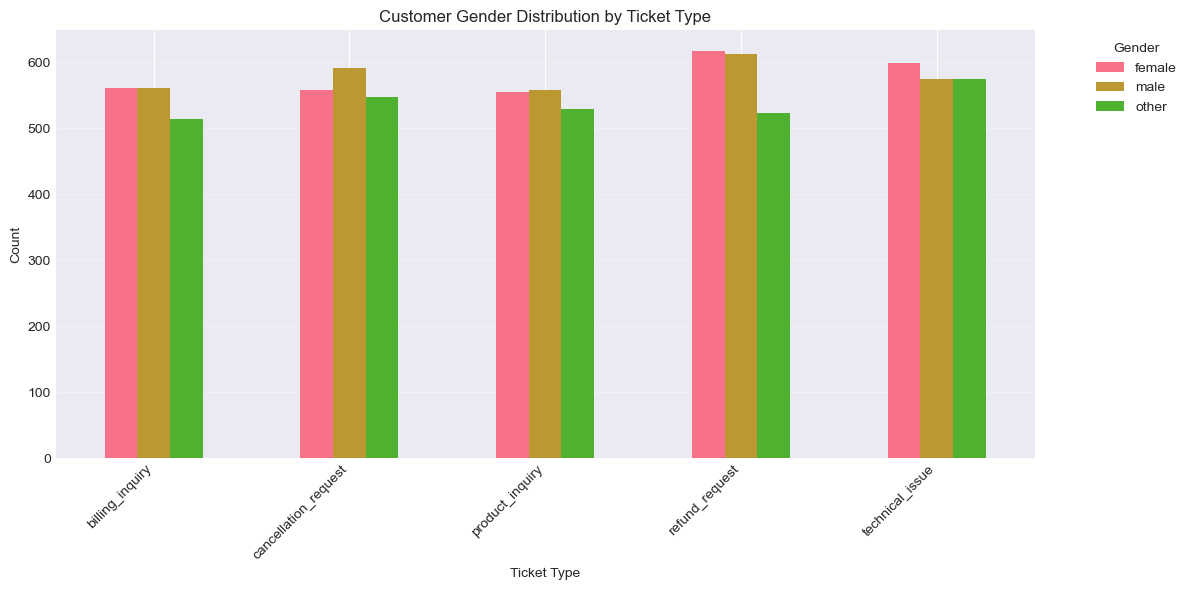

In [30]:
# Gender by ticket type
gender_type_crosstab = pd.crosstab(df['ticket_type'], df['customer_gender'])
print("\nCustomer Gender by Ticket Type:")
print(gender_type_crosstab)

# Stacked bar chart
gender_type_crosstab.plot(kind='bar', stacked=False, figsize=(12, 6))
plt.xlabel('Ticket Type')
plt.ylabel('Count')
plt.title('Customer Gender Distribution by Ticket Type')
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 10. Summary Statistics

In [31]:
# Comprehensive summary
print("="*80)
print("COMPREHENSIVE DATA SUMMARY")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]:,}")
print(f"Total Features: {df.shape[1]}")
print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData Types:")
print(df.dtypes.value_counts())
print(f"\nMissing Values: {df.isnull().sum().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print("\n" + "="*80)
print("KEY INSIGHTS:")
print("="*80)
print(f"1. Most common ticket type: {df['ticket_type'].mode()[0]} ({df['ticket_type'].value_counts().iloc[0]} tickets)")
print(f"2. Most common priority: {df['ticket_priority'].mode()[0]} ({df['ticket_priority'].value_counts().iloc[0]} tickets)")
print(f"3. Most common channel: {df['ticket_channel'].mode()[0]} ({df['ticket_channel'].value_counts().iloc[0]} tickets)")
print(f"4. Average customer age: {df['customer_age'].mean():.1f} years")
print(f"5. Most common gender: {df['customer_gender'].mode()[0]} ({df['customer_gender'].value_counts().iloc[0]} customers)")
print(f"6. Most problematic product: {df['product_purchased'].mode()[0]} ({df['product_purchased'].value_counts().iloc[0]} tickets)")
print("="*80)

COMPREHENSIVE DATA SUMMARY

Dataset Shape: (8469, 8)
Total Records: 8,469
Total Features: 8

Memory Usage: 5.73 MB

Data Types:
object    7
int64     1
Name: count, dtype: int64

Missing Values: 0

Duplicate Rows: 0

KEY INSIGHTS:
1. Most common ticket type: refund_request (1752 tickets)
2. Most common priority: medium (2192 tickets)
3. Most common channel: email (2143 tickets)
4. Average customer age: 44.0 years
5. Most common gender: male (2896 customers)
6. Most problematic product: canon_eos (240 tickets)


------

# Data Preparation for model

In [40]:
print(df.iloc[1])

customer_age                                                         42
customer_gender                                                  female
product_purchased                                           lg_smart_tv
ticket_type                                             technical_issue
ticket_subject                                 peripheral_compatibility
ticket_description    i'm_having_an_issue_with_the_{product_purchase...
ticket_priority                                                critical
ticket_channel                                                     chat
text                  peripheral_compatibility i'm_having_an_issue_w...
Name: 1, dtype: object


In [32]:
df["text"] = df["ticket_subject"] + " " + df["ticket_description"]
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_text = tfidf.fit_transform(df["text"])


In [33]:
X_text

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 132168 stored elements and shape (8469, 5000)>

In [34]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "customer_gender",
    "product_purchased",
    "ticket_channel"
]

encoder = OneHotEncoder(handle_unknown="ignore")
X_cat = encoder.fit_transform(df[categorical_cols])


In [35]:
from scipy.sparse import hstack

X = hstack([X_text, X_cat])
y = df["ticket_type"]


In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y)


LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.